In [ ]:
import numpy as np

def make_signals(T=2*np.pi, N=1000):
    t = np.linspace(0, T, N)/2
    u1 = np.sin(t)
    u2 = np.cos(t)
    return t, u1, u2


In [ ]:
import matplotlib.pyplot as plt

t, u1, u2 = make_signals(T=2*np.pi, N=1000)
prod = u1 * u2

plt.figure(figsize=(10, 6))
plt.plot(t, u1, label='u1(t) = sin(t)')
plt.plot(t, u2, label='u2(t) = cos(t)')
plt.plot(t, prod, label='u1(t)*u2(t)', linestyle=':')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.xlabel('t')
plt.ylabel('значение функции')
plt.title('Пример умножения функций: sin(t) и cos(t)')
plt.show()


In [ ]:
T = 2*np.pi
N = 100000

t, u1, u2 = make_signals(T=T, N=N)
dt = t[1] - t[0]

prod = u1 * u2

I12 = np.sum(prod) * dt
I11 = np.sum(u1 * u1) * dt
I22 = np.sum(u2 * u2) * dt

I12, I11, I22


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры дискретизации
T = 1.0        # длительность сигнала, c
fs = 500.0     # частота дискретизации, Гц
N = int(T * fs)
t = np.linspace(0, T, N, endpoint=False)

# 1) Единичный синус (одна частота)
x1 = np.sin(2 * np.pi * 50 * t)  # 50 Гц

# 2) Сумма двух синусов (две частоты)
x2 = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)  # 50 и 120 Гц

# БПФ (спектры)
X1 = np.fft.fft(x1)
X2 = np.fft.fft(x2)

# Частотная ось
freqs = np.fft.fftfreq(N, d=1/fs)

# Берём только неотрицательные частоты (симметрия спектра)
mask = freqs >= 0
f_pos = freqs[mask]
X1_pos = X1[mask]
X2_pos = X2[mask]

plt.figure(figsize=(10, 6))

# Время: единичный синус
plt.subplot(2, 2, 1)
plt.plot(t, x1)
plt.title('Единичный синус во времени')
plt.xlabel('t, s')
plt.ylabel('x1(t)')
plt.grid(True)

# Частоты: единичный синус
plt.subplot(2, 2, 2)
plt.stem(f_pos, np.abs(X1_pos), basefmt=' ')
plt.title('Спектр единичного синуса')
plt.xlabel('f, Hz')
plt.ylabel('|X1(f)|')
plt.xlim(0, 250)
plt.grid(True)

# Время: сумма двух синусов
plt.subplot(2, 2, 3)
plt.plot(t, x2)
plt.title('Сумма двух синусов во времени')
plt.xlabel('t, s')
plt.ylabel('x2(t)')
plt.grid(True)

# Частоты: сумма двух синусов
plt.subplot(2, 2, 4)
plt.stem(f_pos, np.abs(X2_pos), basefmt=' ')
plt.title('Спектр суммы двух синусов')
plt.xlabel('f, Hz')
plt.ylabel('|X2(f)|')
plt.xlim(0, 250)
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import math
import cmath
from typing import List

def fft_dit(x: List[complex], inverse=False) -> List[complex]:
    N = len(x)
    if N==1:
        return x
    # разбить вектор на чет и нечет
    x_even = x[0::2]
    x_odd = x[1::2]
    B_even = fft_dit(x_even, inverse=inverse)
    B_odd = fft_dit(x_odd, inverse=inverse)

    dir_sign = 1 if inverse else -1
    omega_N = cmath.exp(dir_sign * 2j * math.pi /N)
    omega = 1+0j

    y = [0j] * N
    for j in range(N//2):
        y[j] = B_even[j] + omega * B_odd[j]
        y[j+N//2] = B_even[j] - omega * B_odd[j]
        omega *= omega_N
    return y

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from fft_time_decimation import fft_dit, ifft_dit


# тестовый сигнал: синус одной частоты
N = 256
n = np.arange(N)
x = np.sin(2 * np.pi * 5 * n / N)  # частота 5 "бинов"
x_complex = x.astype(complex)

# мой БПФ
X_my = fft_dit(list(x_complex))
X_my = np.array(X_my)

# БПФ из numpy
X_np = np.fft.fft(x_complex)

# сравнение модулей
k = np.arange(N)

plt.figure(figsize=(10, 4))
plt.stem(k, np.abs(X_my), linefmt='C0-', markerfmt='C0o', basefmt=' ', label='|X_my|')
plt.stem(k, np.abs(X_np), linefmt='C1-', markerfmt='C1x', basefmt=' ', label='|X_np|')
plt.xlim(0, 40)
plt.xlabel('k')
plt.ylabel('|X[k]|')
plt.title('Сравнение спектров: свой БПФ vs numpy.fft.fft')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
np.max(np.abs(X_my - X_np))


In [ ]:
# восстановление сигнала из собственного спектра
x_rec = ifft_dit(list(X_my))
x_rec = np.array(x_rec)

plt.figure(figsize=(10, 4))
plt.plot(n, x, label='исходный x[n]')
plt.plot(n, x_rec.real, '--', label='восстановленный ifft_dit(X_my)')
plt.xlim(0, 50)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# численная ошибка
err = np.max(np.abs(x - x_rec.real))
err


## Свертка двух сигналов

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from convolution import conv_time

# параметры дискретизации
T = 2 * np.pi      # интервал по t
N = 256
t = np.linspace(0, T, N, endpoint=False)

# сигналы во времени
x = 2 * np.sin(t) + 3 * np.cos(t)   # x(t)
y = -np.sin(t)                      # y(t)

# приводим к complex и спискам
x_list = list(x.astype(complex))
y_list = list(y.astype(complex))

# моя свёртка 
s_my = conv_time(x_list, y_list)
s_my = np.array(s_my)

# свёртка numpy (линейная)
s_np = np.convolve(x, y)

# ось времени для результата (просто растянем до 2T)
L = len(s_my)
t_conv = np.linspace(0, 2*T, L, endpoint=False)

# Рисуем три графика друг под другом
plt.figure(figsize=(10, 8))

# 1) x(t)
plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title('Сигнал x(t) = 2 sin(t) + 3 cos(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)

# 2) y(t)
plt.subplot(3, 1, 2)
plt.plot(t, y, color='C1')
plt.title('Сигнал y(t) = -sin(t)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)

# 3) свёртка
plt.subplot(3, 1, 3)
plt.plot(t_conv, s_my.real, label='conv_time (Re)', color='C0')
plt.plot(t_conv, s_np, '--', label='np.convolve', color='C1', alpha=0.7)
plt.title('Свёртка s(t) = x * y')
plt.xlabel('t (условная шкала)')
plt.ylabel('s(t)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# численная разница
err = np.max(np.abs(s_my.real - s_np))
print("Погрешность: " + err.astype(str))


## Свертка через мой БПФ

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from convolution import conv_time, conv_fft

# параметры дискретизации
T = 2 * np.pi
N = 256
t = np.linspace(0, T, N, endpoint=False)

x = 2 * np.sin(t) + 3 * np.cos(t)
y = -np.sin(t)

x_list = list(x.astype(complex))
y_list = list(y.astype(complex))

# свёртка во времени (ручная)
s_time = np.array(conv_time(x_list, y_list))

# свёртка через FFT_В
s_fft = np.array(conv_fft(x_list, y_list))

# свёртка numpy
s_np = np.convolve(x, y)

L = len(s_time)
t_conv = np.linspace(0, 2*T, L, endpoint=False)

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title('x(t) = 2 sin(t) + 3 cos(t)')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, y)
plt.title('y(t) = -sin(t)')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_conv, s_time.real, label='conv_time')
plt.plot(t_conv, s_fft.real, '--', label='conv_fft')
plt.plot(t_conv, s_np, ':', label='np.convolve')
plt.title('Свёртка: во времени vs FFT vs numpy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

err_time_np = np.max(np.abs(s_time.real - s_np))
err_fft_np  = np.max(np.abs(s_fft.real - s_np))

print("Погрешность conv_time: " + err_time_np.astype(str))
print("Погрешность conv_fft: " + err_fft_np.astype(str))


## Корреляция
*в сравнении с numpy*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from correlation import corr_time

# параметры дискретизации
T = 2 * np.pi
N = 256
t = np.linspace(0, T, N, endpoint=False)

# сигналы во времени
x = 2 * np.sin(t) + 3 * np.cos(t)   # x(t)
y = -np.sin(t)                      # y(t)
y = x
# приводим к complex и спискам
x_list = list(x.astype(complex))
y_list = list(y.astype(complex))

# моя корреляция (по определению)
R_my = np.array(corr_time(x_list, y_list))

# корреляция numpy (полная)
R_np = np.correlate(x, y, mode='full')

# ось для корреляции: сдвиги m от -(N-1) до (N-1)
m_vals = np.arange(-(N-1), N)

plt.figure(figsize=(10, 8))

# 1) x(t)
plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title('Сигнал x(t) = 2 sin(t) + 3 cos(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)

# 2) y(t)
plt.subplot(3, 1, 2)
plt.plot(t, y, color='C1')
plt.title('Сигнал y(t) = -sin(t)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)

# 3) корреляция
plt.subplot(3, 1, 3)
plt.plot(m_vals, R_my.real, label='corr_time (Re)', color='C0')
plt.plot(m_vals, R_np, '--', label='np.correlate (full)', color='C1', alpha=0.7)
plt.title('Взаимная корреляция r_xy[m]')
plt.xlabel('m (сдвиг в отсчётах)')
plt.ylabel('r_xy[m]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# численная разница
err = np.max(np.abs(R_my.real - R_np))
print("Погрешность корреляции:", err)


## Корреляция
*в сравнении с версией через БПФ*

len R_time = 511 len R_fft = 511 len R_np = 511


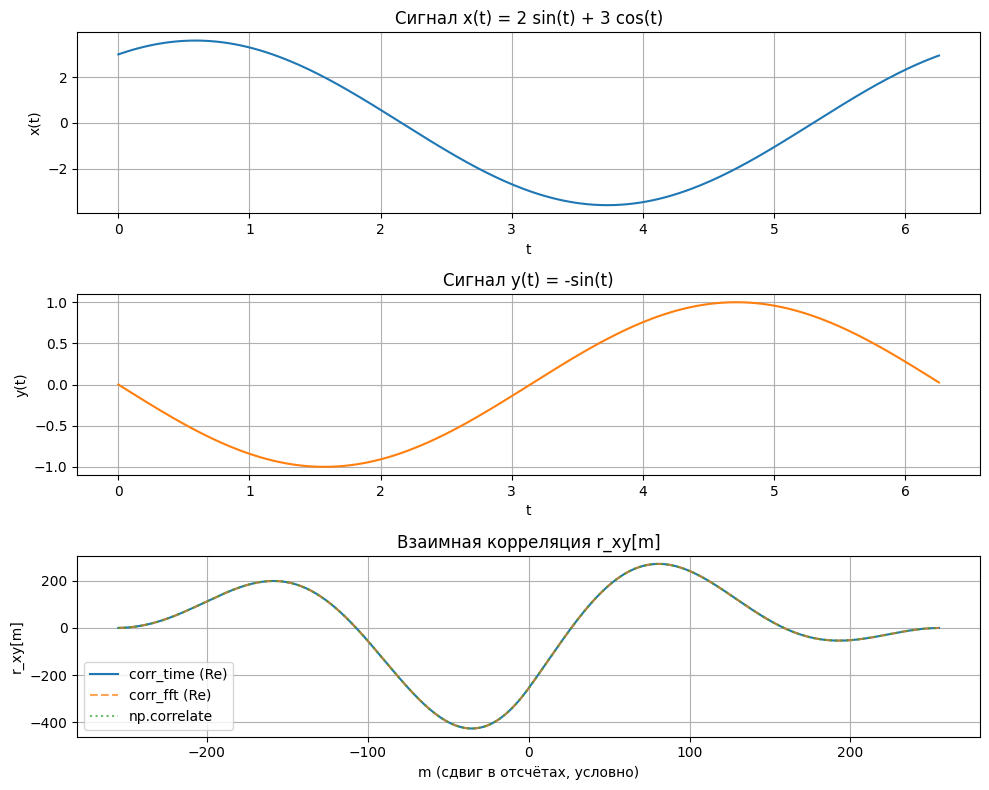

Погрешность corr_fft vs corr_time: 2.5579538487363607e-12
Погрешность np.correlate vs corr_time: 3.979039320256561e-13
Погрешность np.correlate vs corr_fft: 2.3305801732931286e-12


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from correlation import corr_time, corr_fft

# параметры дискретизации
T = 2 * np.pi
N = 256
t = np.linspace(0, T, N, endpoint=False)

# сигналы во времени
x = 2 * np.sin(t) + 3 * np.cos(t)   # x(t)
y = -np.sin(t)                      # y(t)

# к complex и спискам
x_list = list(x.astype(complex))
y_list = list(y.astype(complex))

# 1) корреляция по определению
R_time = np.array(corr_time(x_list, y_list))

# 2) корреляция через БПФ
R_fft = np.array(corr_fft(x_list, y_list))

# 3) корреляция numpy (full)
R_np = np.correlate(x, y, mode='full')

print("len R_time =", len(R_time), "len R_fft =", len(R_fft), "len R_np =", len(R_np))

# для грубого сравнения обрежем до общей длины
L = min(len(R_time), len(R_fft), len(R_np))
R_time_cut = R_time[:L].real
R_fft_cut  = R_fft[:L].real
R_np_cut   = R_np[:L]

# ось сдвигов (условно от -(N-1))
m_vals = np.arange(-(N-1), -(N-1) + L)

plt.figure(figsize=(10, 8))

# 1) x(t)
plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title('Сигнал x(t) = 2 sin(t) + 3 cos(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)

# 2) y(t)
plt.subplot(3, 1, 2)
plt.plot(t, y, color='C1')
plt.title('Сигнал y(t) = -sin(t)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)

# 3) корреляции
plt.subplot(3, 1, 3)
plt.plot(m_vals, R_time_cut, label='corr_time (Re)', color='C0')
plt.plot(m_vals, R_fft_cut,  '--', label='corr_fft (Re)',  color='C1', alpha=0.7)
plt.plot(m_vals, R_np_cut,   ':',  label='np.correlate',    color='C2', alpha=0.7)
plt.title('Взаимная корреляция r_xy[m]')
plt.xlabel('m (сдвиг в отсчётах, условно)')
plt.ylabel('r_xy[m]')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# численные разницы на общей части
err_fft_time = np.max(np.abs(R_time_cut - R_fft_cut))
err_np_time  = np.max(np.abs(R_time_cut - R_np_cut))
err_np_fft   = np.max(np.abs(R_fft_cut  - R_np_cut))

print("Погрешность corr_fft vs corr_time:", err_fft_time)
print("Погрешность np.correlate vs corr_time:", err_np_time)
print("Погрешность np.correlate vs corr_fft:", err_np_fft)
